In [1]:
from utils import *
import numpy as np

In [2]:
# Load setting:
from general_settings import *

In [3]:
# x_opt = np.array([50., 0., 0., 0., 0.])
# x_opt = np.array([21.19567472, 48.72482769, 49.01709614, 42.92404163, 38.13835983])         # Optimized for I_0 = 200, alpha = 0.3, b = 10^(-4).
# x_opt = np.array([21.06977056, 49.38434609, 48.7067262 , 42.08096165, 38.7581955 ])       # Optimized for alpha = 0.8
# x_opt = np.array([24.63359425, 44.24856542, 48.70578173, 43.17252143, 39.23953717])        # Optimized for I_0 = 200, alpha = 0.3, b = 10^(-3)
x_opt = np.array([24.39411337, 41.44442694, 54.41733041, 43.03396861, 36.71016067])
omega = np.array([20 * np.pi, 30 * np.pi, 40 * np.pi, 50 * np.pi, 60 * np.pi])
size_omega = len(omega)
list_i_prime_funcs = np.array([omega[i] * np.cos(omega[i] * simulation_times) for i in range(size_omega)])
i_true_time = x_opt.dot(list_i_prime_funcs)
f_true = space_time_mult(i_true_time, u_init, M_matrix, simulation_times)
# Zero vectors:
zero_vec = init_vector(M_matrix, 0)
zero_time_vec = init_time_vector(M_matrix, simulation_times, 0)

In [4]:
# Parameter:
c_expr = fn.Constant(c)
# alpha = 0.1
alpha = 0.3
# alpha = 0.8
b = (-(2 * c) / np.cos(np.pi * (alpha + 1)/ 2))
print(b)
# b = 191.77/1e3
b = 66.08/1e3
# b = 31.54/1e3
parameter = [c_expr, b, alpha]

66.08067793755801


In [5]:
# Observation operator:
u_trial, u_test = fn.TrialFunction(V), fn.TestFunction(V)
B_matrix = fn.assemble(fn.inner(u_trial('+'), u_test('+')) * ds(1))
_misfit = WaveSpaceTimeStateObservation(V, simulation_times, simulation_times, B_matrix)

# Prior distribution:
l = 0.01
sigma = 0.1
f = lambda x, y:  l * np.exp(-(np.abs(x[0] - y[0]) + np.abs(x[1] - y[1]))/sigma)
grid = V.tabulate_dof_coordinates()
covariance = comp_covariance(grid, f)
eigvals, eigvecs = np.linalg.eigh(covariance)
prior_gaussian = GaussianPrior(V, covariance)
_prior = prior_gaussian

In [6]:
from WaveSolver import *
WaveNewModel = WaveInverseDamped(V, simulation_times, _misfit, _prior, parameter)

In [7]:
design = i_true_time
X_zero = WaveNewModel.generate_vector()
X_zero[PARAMETER][:] = u_init[:]
WaveNewModel.solveFwd(X_zero[STATE], X_zero, design)
WaveNewModel.misfit.p_obs = X_zero[STATE].copy()
WaveNewModel.misfit.noise_variance = 1e-2
parRandom.normal_perturb(WaveNewModel.misfit.noise_variance, WaveNewModel.misfit.p_obs)
print(WaveNewModel.cost(X_zero))

[0.003887253554053876, 0.0022693870643331494, 0.0016178664897207266]


In [8]:
from Jacobian import *
design = i_true_time
J_new = Jacobian_PAT(WaveNewModel, design)
H_new = Hessian_PAT(WaveNewModel, design)

In [9]:
k = 80
p = 20
print( "Single Pass Algorithm. Requested eigenvectors: {0}; Oversampling {1}.".format(k, p))
prior_test = LaplacianPrior(V, 0.1, 8.)
Omega = MultiVector(X_zero[PARAMETER], k + p)
parRandom.normal(1., Omega)
lmbda, Z = singlePassG(H_new, prior_test.R, prior_test.Rsolver, Omega, k)
_posterior = GaussianLRPosterior(prior_test, lmbda, Z)

Single Pass Algorithm. Requested eigenvectors: 80; Oversampling 20.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forwar

In [ ]:
X_iter_2 = WaveNewModel.generate_vector()
solution = np.load('data_function/edge_03_2000_opt_103.npy')
u_comp = init_vector_numpy(solution)
X_iter_2[PARAMETER][:] = u_comp[:]
SteinhaugSolver = CGSolverSteihaug()
SteinhaugSolver.set_operator(J_new)
SteinhaugSolver.set_preconditioner(_posterior.Hlr)
SteinhaugSolver.parameters["print_level"] = 1
SteinhaugSolver.parameters["rel_tolerance"] = 1e-3
SteinhaugSolver.parameters["abs_tolerance"] = 1e-2
SteinhaugSolver.parameters["max_iter"] = 1500
SteinhaugSolver.parameters["zero_initial_guess"] = False
SteinhaugSolver.solve(X_iter_2[PARAMETER], J_new.M_b)

Relative L2 error:  0.2477628190278081


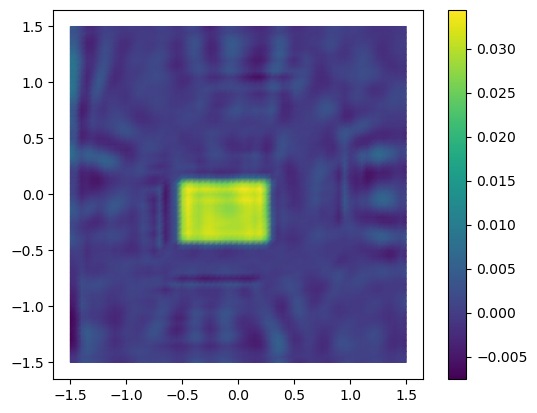

In [25]:
diff = X_iter_2[PARAMETER] - X_zero[PARAMETER]
norm = np.sqrt(diff.inner(M_matrix * diff))
norm_zero = np.sqrt(X_zero[PARAMETER].inner(M_matrix * X_zero[PARAMETER]))
print('Relative L2 error: ', norm/norm_zero)

nb.plot(fn.Function(V, X_iter_2[PARAMETER]), colorbar=False, show_axis='on')
plt.colorbar(pad = 0.05)
plt.show()

In [26]:
# Export solution to numpy:
np.save('data_function/edge_03_2000_opt_103.npy', X_iter_2[PARAMETER][:])

In [14]:
# Check result:
solution = np.load('data_function/edge_08_50_20init_103.npy')
u_comp = init_vector_numpy(solution)
diff = u_comp - X_zero[PARAMETER]
norm_sub = np.sqrt(diff.inner(M_matrix_sub * diff))
norm_zero_sub = np.sqrt(X_zero[PARAMETER].inner(M_matrix_sub * X_zero[PARAMETER]))

norm_full = np.sqrt(diff.inner(M_matrix * diff))
norm_zero_full = np.sqrt(X_zero[PARAMETER].inner(M_matrix * X_zero[PARAMETER]))
# print('Relative L2 error sub : ', norm_sub /norm_zero_sub  * 100)
print('Relative L2 error full: ', norm_full/norm_zero_full * 100)

Relative L2 error full:  40.094834919452246
